In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

In [ ]:
covid_df = pd.read_csv('/content/country_wise_latest.csv')
happy_df = pd.read_csv("/content/complete.csv")

covid_df.head()
happy_df.head()

,Date,Name of State / UT,Latitude,Longitude,Total Confirmed cases,Death,Cured/Discharged/Migrated,New cases,New deaths,New recovered
0,2020-01-30,Kerala,10.8505,76.2711,1.0,0,0.0,0,0,0
1,2020-01-31,Kerala,10.8505,76.2711,1.0,0,0.0,0,0,0
2,2020-02-01,Kerala,10.8505,76.2711,2.0,0,0.0,1,0,0
3,2020-02-02,Kerala,10.8505,76.2711,3.0,0,0.0,1,0,0
4,2020-02-03,Kerala,10.8505,76.2711,3.0,0,0.0,0,0,0


In [7]:
# Data Understanding

covid_df.info()
covid_df.describe()

happy_df.info()
happy_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Region          187 non-null    object 
 1   Confirmed               187 non-null    int64  
 2   Deaths                  187 non-null    int64  
 3   Recovered               187 non-null    int64  
 4   Active                  187 non-null    int64  
 5   New cases               187 non-null    int64  
 6   New deaths              187 non-null    int64  
 7   New recovered           187 non-null    int64  
 8   Deaths / 100 Cases      187 non-null    float64
 9   Recovered / 100 Cases   187 non-null    float64
 10  Deaths / 100 Recovered  187 non-null    float64
 11  Confirmed last week     187 non-null    int64  
 12  1 week change           187 non-null    int64  
 13  1 week % increase       187 non-null    float64
 14  WHO Region              187 non-null    ob

,Latitude,Longitude,Total Confirmed cases,Cured/Discharged/Migrated,New cases,New deaths,New recovered
count,4692.000000,4692.000000,4692.000000,4692.000000,4692.000000,4692.0,4692.000000
mean,23.185327,81.451837,11393.925192,6908.130648,418.643009,0.0,283.069054
std,6.635913,6.959475,37208.600846,23390.671258,1259.748923,0.0,947.925811
min,0.000000,0.000000,1.000000,0.000000,0.000000,0.0,-1.000000
25%,18.112400,76.271100,39.000000,9.000000,1.000000,0.0,0.000000
50%,23.940800,79.019300,619.000000,197.500000,26.000000,0.0,8.000000
75%,28.218000,85.313100,5233.000000,2736.000000,210.250000,0.0,119.000000
max,34.299600,94.727800,468265.000000,305521.000000,18366.000000,0.0,13401.000000


In [8]:
covid_df.isnull().sum()
happy_df.isnull().sum()

covid_df.fillna(0, inplace=True)
happy_df.dropna(inplace=True)

In [9]:
#
covid_df.rename(columns={"Country/Region": "Country"}, inplace=True)

In [10]:
# Total cases per country
covid_country = covid_df.groupby("Country").sum()
covid_country.head()

,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
Country,,,,,,,,,,,,,,
Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


In [11]:
covid_country["Death Rate"] = covid_country["Deaths"] / covid_country["Confirmed"]
covid_country["Recovery Rate"] = covid_country["Recovered"] / covid_country["Confirmed"]

In [13]:
# Merge Both Datasets
# Add 'Country' column to happy_df since it's India-specific state data
happy_df['Country'] = 'India'

merged_df = covid_country.merge(happy_df, on="Country")
merged_df.head()

,Country,Confirmed,Deaths,Recovered,Active,New cases_x,New deaths_x,New recovered_x,Deaths / 100 Cases,Recovered / 100 Cases,...,Date,Name of State / UT,Latitude,Longitude,Total Confirmed cases,Death,Cured/Discharged/Migrated,New cases_y,New deaths_y,New recovered_y
0,India,1480073,33408,951166,495499,44457,637,33598,2.26,64.26,...,2020-01-30,Kerala,10.8505,76.2711,1.0,0,0.0,0,0,0
1,India,1480073,33408,951166,495499,44457,637,33598,2.26,64.26,...,2020-01-31,Kerala,10.8505,76.2711,1.0,0,0.0,0,0,0
2,India,1480073,33408,951166,495499,44457,637,33598,2.26,64.26,...,2020-02-01,Kerala,10.8505,76.2711,2.0,0,0.0,1,0,0
3,India,1480073,33408,951166,495499,44457,637,33598,2.26,64.26,...,2020-02-02,Kerala,10.8505,76.2711,3.0,0,0.0,1,0,0
4,India,1480073,33408,951166,495499,44457,637,33598,2.26,64.26,...,2020-02-03,Kerala,10.8505,76.2711,3.0,0,0.0,0,0,0


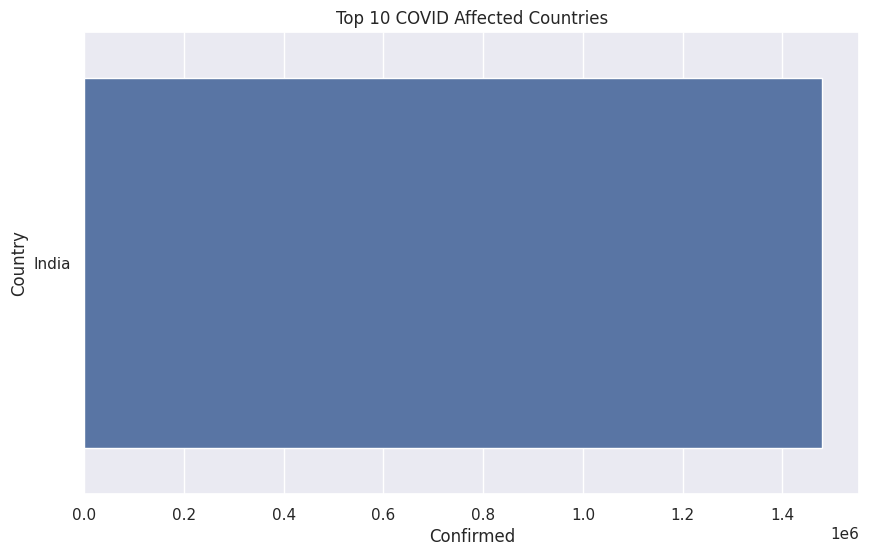

In [14]:
# Top Affected Countries

top = merged_df.sort_values(by="Confirmed", ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x="Confirmed", y="Country", data=top)
plt.title("Top 10 COVID Affected Countries")
plt.show()

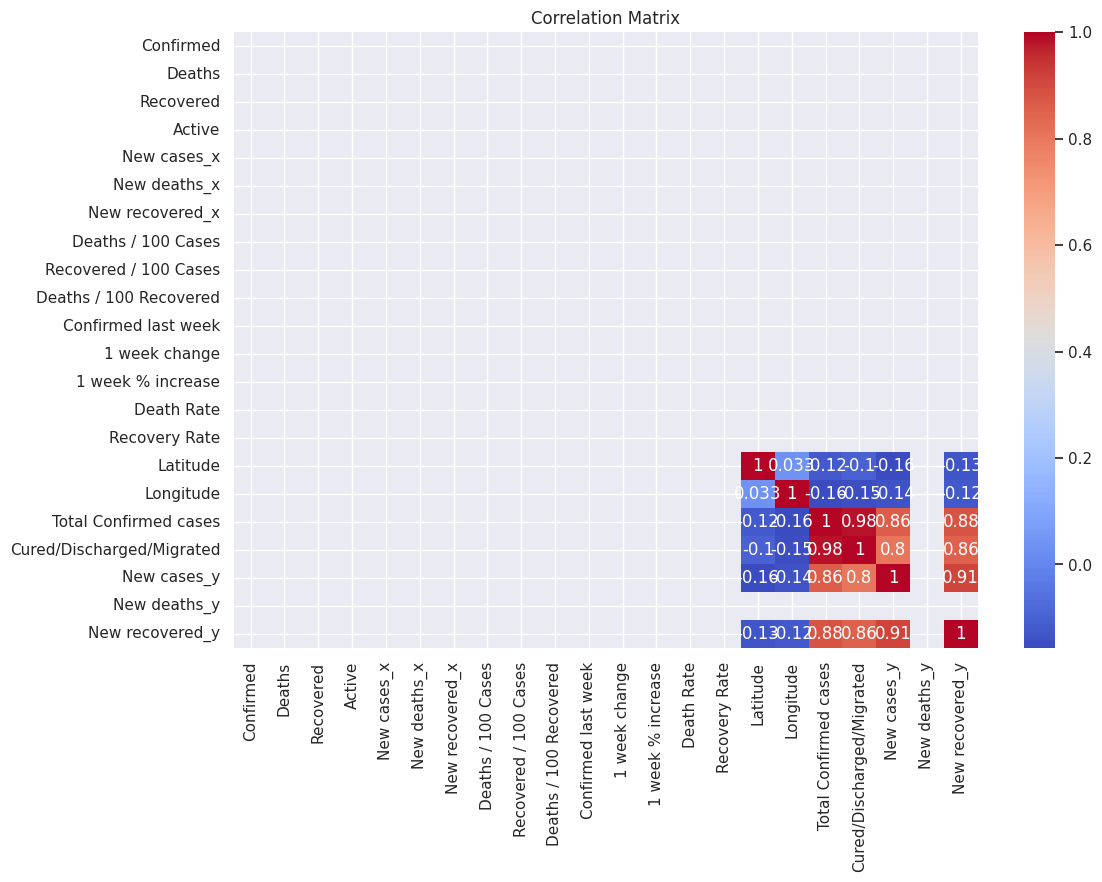

In [16]:
plt.figure(figsize=(12,8))
# Select only numeric columns before calculating correlation to avoid errors with string columns
numeric_merged_df = merged_df.select_dtypes(include=np.number)
sns.heatmap(numeric_merged_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

First, we need a dataset containing GDP per capita information for various countries. For demonstration purposes, I will create a dummy DataFrame. In a real scenario, you would load this from a CSV file or another source.

**Action required**: Please replace the dummy `gdp_df` creation with loading your actual GDP data. Ensure your GDP data has a 'Country' column (matching the `Country` column in `covid_country`) and a 'GDP per capita' column.

In [18]:
import pandas as pd

# --- Placeholder for loading your actual GDP data ---
# Replace this with your actual GDP data loading, e.g.:
# gdp_df = pd.read_csv('path/to/your/gdp_per_capita_data.csv')

# Example dummy GDP DataFrame (replace with real data)
dummy_gdp_data = {
    'Country': ['India', 'US', 'Brazil', 'Russia', 'France', 'UK', 'Italy', 'Germany', 'Spain', 'Peru'],
    'GDP per capita': [2100, 65000, 9000, 11000, 42000, 40000, 35000, 46000, 30000, 7000]
}
gdp_df = pd.DataFrame(dummy_gdp_data)

print("Dummy GDP Data:")
display(gdp_df.head())


Dummy GDP Data:


,Country,GDP per capita
0,India,2100
1,US,65000
2,Brazil,9000
3,Russia,11000
4,France,42000


Now, we will merge the `covid_country` DataFrame (which contains the COVID-19 confirmed cases by country) with our `gdp_df` using the 'Country' column.

In [19]:
# Merge covid_country with gdp_df
# Note: Using covid_country here as it's aggregated by country, which makes more sense for GDP data.
# The previous `merged_df` was primarily for state-level data within India.
country_gdp_covid_df = covid_country.merge(gdp_df, on='Country', how='left')

print("Merged DataFrame with GDP and COVID data:")
display(country_gdp_covid_df.head())


Merged DataFrame with GDP and COVID data:


,Country,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region,Death Rate,Recovery Rate,GDP per capita
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean,0.034994,0.694868,NaN
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe,0.029508,0.562500,NaN
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa,0.041576,0.673399,NaN
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe,0.057332,0.885336,NaN
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa,0.043158,0.254737,NaN


Now that we have 'GDP per capita' in our `country_gdp_covid_df`, we can create the scatter plot.

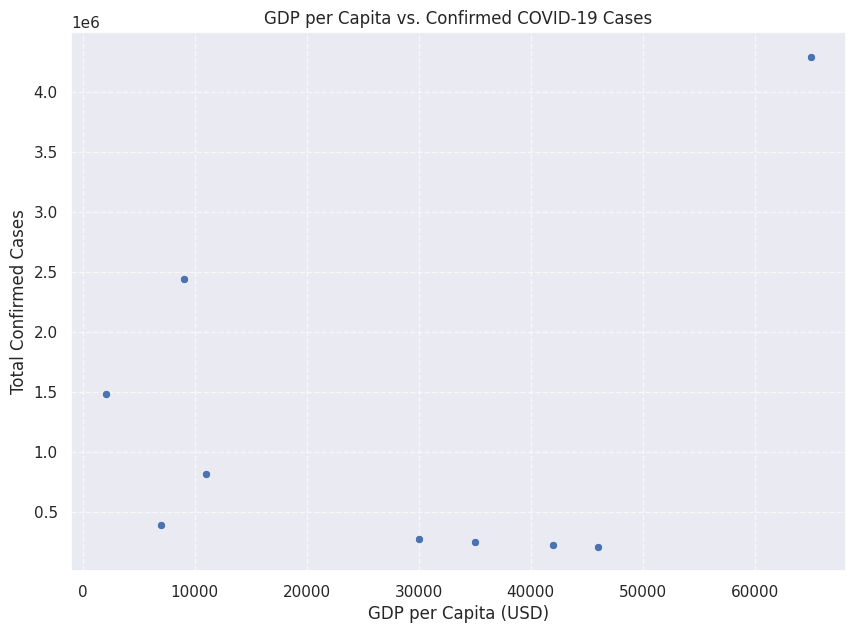

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x="GDP per capita", y="Confirmed", data=country_gdp_covid_df)
plt.title("GDP per Capita vs. Confirmed COVID-19 Cases")
plt.xlabel("GDP per Capita (USD)")
plt.ylabel("Total Confirmed Cases")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


To plot 'Happiness Score' against 'Death Rate', we first need a dataset containing happiness scores for various countries. For demonstration purposes, I will create a dummy DataFrame. In a real scenario, you would load this from a CSV file or another source.

**Action required**: Please replace the dummy `happiness_df` creation with loading your actual happiness score data. Ensure your happiness data has a 'Country' column (matching the `Country` column in `covid_country`) and a 'Happiness Score' column.

In [22]:
import pandas as pd

# --- Placeholder for loading your actual Happiness Score data ---
# Replace this with your actual Happiness Score data loading, e.g.:
# happiness_df = pd.read_csv('path/to/your/happiness_score_data.csv')

# Example dummy Happiness Score DataFrame (replace with real data)
dummy_happiness_data = {
    'Country': ['India', 'US', 'Brazil', 'Russia', 'France', 'UK', 'Italy', 'Germany', 'Spain', 'Peru'],
    'Happiness Score': [3.5, 7.0, 6.1, 5.5, 6.4, 7.1, 6.0, 7.2, 6.3, 5.0]
}
happiness_df = pd.DataFrame(dummy_happiness_data)

print("Dummy Happiness Data:")
display(happiness_df.head())


Dummy Happiness Data:


,Country,Happiness Score
0,India,3.5
1,US,7.0
2,Brazil,6.1
3,Russia,5.5
4,France,6.4


Now, we will merge the `covid_country` DataFrame (which contains the COVID-19 death rates by country) with our `happiness_df` using the 'Country' column to create a combined dataset for plotting.

In [23]:
# Merge covid_country with happiness_df
# We'll use covid_country as it contains the 'Death Rate' per country.
country_happiness_covid_df = covid_country.merge(happiness_df, on='Country', how='left')

print("Merged DataFrame with Happiness Score and COVID data:")
display(country_happiness_covid_df.head())


Merged DataFrame with Happiness Score and COVID data:


,Country,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region,Death Rate,Recovery Rate,Happiness Score
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean,0.034994,0.694868,NaN
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe,0.029508,0.562500,NaN
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa,0.041576,0.673399,NaN
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe,0.057332,0.885336,NaN
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa,0.043158,0.254737,NaN


Now that we have 'Happiness Score' and 'Death Rate' in our `country_happiness_covid_df`, we can create the scatter plot.

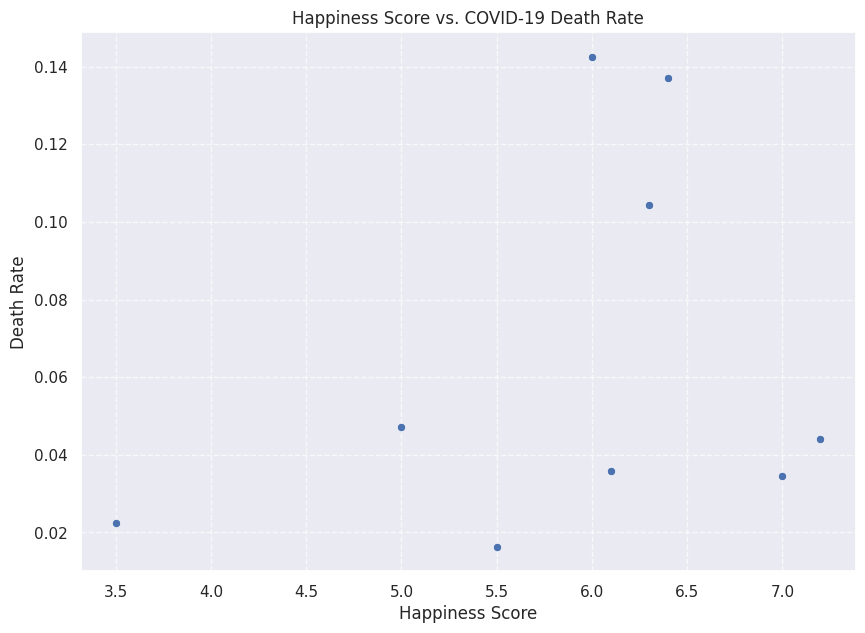

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x="Happiness Score", y="Death Rate", data=country_happiness_covid_df)
plt.title("Happiness Score vs. COVID-19 Death Rate")
plt.xlabel("Happiness Score")
plt.ylabel("Death Rate")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
